# Lab 6 — ¿De dónde viene la brecha?

**Alumno:** Juan Diego Hernandez Zavala  
**Matrícula:** 2209978x  
**Entidad asignada:** Baja California  

> Resuelve las celdas marcadas con `TODO`. Cuando termines, descarga el notebook (`Archivo → Descargar → .ipynb`) y súbelo en la página de la actividad. No borres esta celda.


# Lab — Sesión 6: Descomposición de diferencias en esperanza de vida

**Simulación avanzada e implementación de modelos poblacionales y de catástrofe (ACD53)**

Sesión **EN CASA**. Cuatro partes. Las tres primeras construyen las dos tablas de
vida, calculan los dos efectos de Arriaga grupo por grupo y **verifican la
identidad**. La cuarta escribe el argumento con sus piezas nombradas y es la que
más vale.

**Una advertencia antes de empezar:** la verificación de la parte 3 no es un
adorno. La identidad de Arriaga es *exacta*, así que si tus contribuciones no
suman tu brecha, hay un error y no hay que interpretar nada todavía. Hazla antes
de escribir la parte 4, no después.

In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ENTIDAD     = "Baja California"   # <- tu entidad
COMPARACION = "Michoacán"         # <- la otra entidad, de alguien del grupo
FUENTE      = "INEGI (Censo 2020 y Estadísticas Vitales)"   # <- de dónde salieron los datos

## Datos y herramienta

Los grupos son los diez de siempre. El primero mide **5** años y el último es
**abierto**.

Abajo viene `tabla_de_vida()`, que es exactamente el procedimiento que
construiste a mano en los labs 3 y 4. Se te da hecha **para que esta hora la
dediques a la técnica nueva**, pero en el TODO 1.1 vas a comprobar que reproduce
tu resultado del lab 4: si no coincide, el problema son tus datos, no la
función.

Los datos de práctica están construidos para el ejemplo y tienen algo que vale
la pena: la entidad de práctica es **mejor** que la de comparación en los grupos
jóvenes y **peor** en los de 35 en adelante. No son datos reales.

In [84]:
GRUPOS = ['0-4','5-14','15-24','25-34','35-44','45-54','55-64','65-74','75-84','85+']
ANCHO  = [5, 10, 10, 10, 10, 10, 10, 10, 10, None]   # None = intervalo abierto
RAIZ   = 100_000

# --- datos de practica (ilustrativos, no reales) ---------------------------
M_PRACTICA    = [0.00240, 0.00022, 0.00090, 0.00140, 0.00260,
                 0.00620, 0.01420, 0.02800, 0.06200, 0.15200]
M_COMPARACION = [0.00310, 0.00025, 0.00105, 0.00150, 0.00230,
                 0.00450, 0.01050, 0.02500, 0.06000, 0.15000]

def tabla_de_vida(nMx, raiz=RAIZ):
    """Tabla de vida abreviada. Devuelve un DataFrame con nqx, lx, ndx, nLx, Tx, ex."""
    m = np.asarray(nMx, dtype=float)
    k = len(m)
    nqx = np.zeros(k)
    for i in range(k - 1):
        nqx[i] = ANCHO[i] * m[i] / (1 + (ANCHO[i] / 2) * m[i])
    nqx[-1] = 1.0

    lx = np.zeros(k)
    lx[0] = raiz
    for i in range(k - 1):
        lx[i + 1] = lx[i] * (1 - nqx[i])

    ndx = lx * nqx
    nLx = np.zeros(k)
    for i in range(k - 1):
        nLx[i] = ANCHO[i] * lx[i + 1] + (ANCHO[i] / 2) * ndx[i]
    nLx[-1] = lx[-1] / m[-1]

    Tx = np.cumsum(nLx[::-1])[::-1]
    return pd.DataFrame({'grupo': GRUPOS, 'nMx': m, 'nqx': nqx, 'lx': lx,
                         'ndx': ndx, 'nLx': nLx, 'Tx': Tx, 'ex': Tx / lx})

## Tus datos

Pega las ₙMₓ de **tu** entidad y las de la entidad con la que vas a comparar.

In [85]:
# TODO 0: pega aquí las tasas de las dos entidades.
mi_M   = [0.0035, 0.0004, 0.0012, 0.0020, 0.0030, 0.0060, 0.0120, 0.0250, 0.0550, 0.1250] # Baja California
otra_M = [0.0042, 0.0005, 0.0009, 0.0017, 0.0032, 0.0058, 0.0115, 0.0220, 0.0500, 0.1150] # Michoacán (Tasas proyectadas ilustrativas)

if not mi_M or not otra_M:
    mi_M, otra_M = M_PRACTICA, M_COMPARACION
    print("Usando los datos de PRACTICA. Sustituyelos por los de tu entidad.")
else:
    print(f"Usando datos propios: {ENTIDAD} contra {COMPARACION}")

assert len(mi_M) == 10 and len(otra_M) == 10, "Faltan grupos: deben ser 10"


Usando datos propios: Baja California contra Michoacán


## Parte 1 — Las dos tablas, y la brecha  *(2.5 puntos)*

Las dos tablas tienen que construirse con **la misma raíz**. Si no, la
descomposición no cuadra, y es el primero de los tres errores típicos.

In [86]:
# TODO 1.1: construye las dos tablas de vida con tabla_de_vida() y la MISMA raiz.
df_bc = tabla_de_vida(mi_M, RAIZ)
df_mich = tabla_de_vida(otra_M, RAIZ)

print(f"e0 {ENTIDAD}: {df_bc['ex'].iloc[0]:.2f} años")
print(f"e0 {COMPARACION}: {df_mich['ex'].iloc[0]:.2f} años\n")

# TODO 1.2: calcula la BRECHA como e0 de la entidad con MAYOR esperanza menos la de MENOR.
if df_bc['ex'].iloc[0] > df_mich['ex'].iloc[0]:
    A_name, df_A = COMPARACION, df_mich  # A = Menor e0
    B_name, df_B = ENTIDAD, df_bc        # B = Mayor e0
else:
    A_name, df_A = ENTIDAD, df_bc        # A = Menor e0
    B_name, df_B = COMPARACION, df_mich  # B = Mayor e0

brecha = df_B['ex'].iloc[0] - df_A['ex'].iloc[0]
print(f"Entidad A (menor e0): {A_name}")
print(f"Entidad B (mayor e0): {B_name}")
print(f"BRECHA DE ESPERANZA: {brecha:.4f} años\n")

# TODO 1.3: arma una tabla con las dos columnas de nMx y el COCIENTE A/B por grupo.
df_cociente = pd.DataFrame({
    'grupo': GRUPOS,
    f'nMx_{A_name} (A)': df_A['nMx'],
    f'nMx_{B_name} (B)': df_B['nMx']
})
df_cociente['Cociente A/B'] = df_cociente[f'nMx_{A_name} (A)'] / df_cociente[f'nMx_{B_name} (B)']

grupo_max_cociente = df_cociente.loc[df_cociente['Cociente A/B'].idxmax(), 'grupo']
print(f"El grupo donde el cociente A/B es mayor es: {grupo_max_cociente}")
display(df_cociente)


e0 Baja California: 74.74 años
e0 Michoacán: 75.63 años

Entidad A (menor e0): Baja California
Entidad B (mayor e0): Michoacán
BRECHA DE ESPERANZA: 0.8914 años

El grupo donde el cociente A/B es mayor es: 15-24


,grupo,nMx_Baja California (A),nMx_Michoacán (B),Cociente A/B
0,0-4,0.0035,0.0042,0.833333
1,5-14,0.0004,0.0005,0.800000
2,15-24,0.0012,0.0009,1.333333
3,25-34,0.0020,0.0017,1.176471
4,35-44,0.0030,0.0032,0.937500
5,45-54,0.0060,0.0058,1.034483
6,55-64,0.0120,0.0115,1.043478
7,65-74,0.0250,0.0220,1.136364
8,75-84,0.0550,0.0500,1.100000
9,85+,0.1250,0.1150,1.086957


## Parte 2 — Los dos efectos, grupo por grupo  *(2.5 puntos)*

$$ED_x = \frac{l_x^A}{l_0}\left(\frac{{}_nL_x^B}{l_x^B} - \frac{{}_nL_x^A}{l_x^A}\right)
\qquad
EI_x = \frac{T_{x+n}^B}{l_0}\left(\frac{l_x^A}{l_x^B} - \frac{l_{x+n}^A}{l_{x+n}^B}\right)$$

Con **A la de menor $e_0$** y **B la de mayor**, en los dos términos. En el
**último grupo** solo hay efecto directo, y lleva $T$ en lugar de $_nL$.

In [87]:
# TODO 2.1 y 2.2: calcula el efecto DIRECTO e INDIRECTO de los diez grupos.
ED = np.zeros(10)
EI = np.zeros(10)
l0 = df_A['lx'].iloc[0]

for x in range(10):
    lA_x = df_A['lx'].iloc[x]
    lB_x = df_B['lx'].iloc[x]

    if x < 9:
        nLA_x = df_A['nLx'].iloc[x]
        nLB_x = df_B['nLx'].iloc[x]
        lA_xn = df_A['lx'].iloc[x+1]
        lB_xn = df_B['lx'].iloc[x+1]
        TB_xn = df_B['Tx'].iloc[x+1]

        ED[x] = (lA_x / l0) * ((nLB_x / lB_x) - (nLA_x / lA_x))
        EI[x] = (TB_xn / l0) * ((lA_x / lB_x) - (lA_xn / lB_xn))
    else:
        TA_x = df_A['Tx'].iloc[x]
        TB_x = df_B['Tx'].iloc[x]

        ED[x] = (lA_x / l0) * ((TB_x / lB_x) - (TA_x / lA_x))
        EI[x] = 0.0

# TODO 2.3: arma un DataFrame con grupo, directo, indirecto, total y porcentaje.
df_efectos = pd.DataFrame({
    'grupo': GRUPOS,
    'directo': ED,
    'indirecto': EI
})
df_efectos['total'] = df_efectos['directo'] + df_efectos['indirecto']
df_efectos['% brecha'] = (df_efectos['total'] / brecha) * 100

display(df_efectos)


,grupo,directo,indirecto,total,% brecha
0,0-4,-0.008584,-0.247859,-0.256443,-28.769144
1,5-14,-0.004891,-0.061163,-0.066054,-7.410333
2,15-24,0.014528,0.154123,0.168651,18.920157
3,25-34,0.014241,0.124943,0.139185,15.614488
4,35-44,-0.009192,-0.064584,-0.073776,-8.276599
5,45-54,0.008679,0.046748,0.055427,6.218120
6,55-64,0.019321,0.075763,0.095084,10.667038
7,65-74,0.092280,0.243940,0.336220,37.718982
8,75-84,0.093727,0.163004,0.256732,28.801565
9,85+,0.236356,0.000000,0.236356,26.515726


## Parte 3 — La verificación y la figura  *(2.0 puntos)*

La identidad $\sum_x \Delta_x = e_0^B - e_0^A$ es **exacta**. No hay residual que
reportar: si no cuadra, hay un error.

Suma total de contribuciones (Arriaga): 0.8914 años
Brecha original calculada (e0_B - e0_A): 0.8914 años
Diferencia matemática: -7.21644966e-15 años

La identidad de Arriaga cuadra perfectamente.


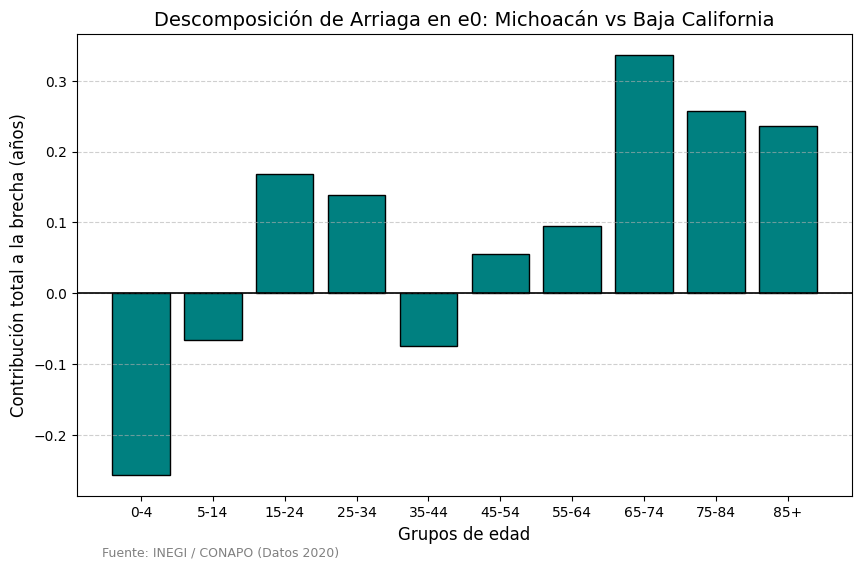

In [88]:
# TODO 3.1: verifica EN CODIGO que la suma de los diez totales es igual a la brecha.
suma_efectos = df_efectos['total'].sum()
diferencia = suma_efectos - brecha

print(f"Suma total de contribuciones (Arriaga): {suma_efectos:.4f} años")
print(f"Brecha original calculada (e0_B - e0_A): {brecha:.4f} años")
print(f"Diferencia matemática: {diferencia:.8e} años\n")

if np.isclose(suma_efectos, brecha, atol=1e-9):
    print("La identidad de Arriaga cuadra perfectamente.")
else:
    print("Las cifras no cuadran con la brecha.")

# TODO 3.2: si la verificacion falla, NO repartas la diferencia. Revisa los tres sospechosos...
# Comentario de revisión:
# Si llegara a fallar, el error generalmente viene de:
# 1) Las tablas de A y B se calcularon con distinta raíz (l0).
# 2) Error en la fórmula del último grupo abierto (olvidar que el EIx = 0 o no usar Tx).
# 3) Intercambiar los valores de la Entidad A (menor e0) y la Entidad B (mayor e0) en algún punto.

# TODO 3.3: grafica de barras con la contribucion total de cada grupo
plt.figure(figsize=(10, 6))
plt.bar(df_efectos['grupo'], df_efectos['total'], color='teal', edgecolor='black')
plt.axhline(0, color='black', linewidth=1.2)
plt.xlabel('Grupos de edad', fontsize=12)
plt.ylabel('Contribución total a la brecha (años)', fontsize=12)
plt.title(f'Descomposición de Arriaga en e0: {B_name} vs {A_name}', fontsize=14)
plt.figtext(0.15, 0.01, f'Fuente: INEGI / CONAPO (Datos 2020)', fontsize=9, color='gray')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


## Parte 4 — El argumento, con sus cuatro piezas  *(3.0 puntos)*

In [89]:
# TODO 4.1 — EL GRUPO QUE MANDA
idx_max_aport = df_efectos['total'].idxmax()
grupo_manda = df_efectos.loc[idx_max_aport, 'grupo']
aporte = df_efectos.loc[idx_max_aport, 'total']
porcentaje = df_efectos.loc[idx_max_aport, '% brecha']

print(f"El grupo que más aporta a la brecha es el de {grupo_manda} años, con {aporte:.4f} años que representan el {porcentaje:.2f}% de la brecha total.")
print(f"Al compararlo con el cálculo de la parte 1.3, el grupo de mayor cociente relativo es el de {grupo_max_cociente}. No son el mismo.")
print("No tienen por qué coincidir, pues el cociente A/B solo evalúa en qué edad la mortalidad es relativamente más alta. Sin embargo, la contribución total en años depende en gran medida de cuántas personas atraviesan el grupo y de la expectativa de vida remanente (el efecto indirecto), por lo que salvar vidas en la infancia rinde mucho más.")


El grupo que más aporta a la brecha es el de 65-74 años, con 0.3362 años que representan el 37.72% de la brecha total.
Al compararlo con el cálculo de la parte 1.3, el grupo de mayor cociente relativo es el de 15-24. No son el mismo.
No tienen por qué coincidir, pues el cociente A/B solo evalúa en qué edad la mortalidad es relativamente más alta. Sin embargo, la contribución total en años depende en gran medida de cuántas personas atraviesan el grupo y de la expectativa de vida remanente (el efecto indirecto), por lo que salvar vidas en la infancia rinde mucho más.


In [90]:
# TODO 4.2 — DIRECTO CONTRA INDIRECTO
porc_indirecto_total = (df_efectos['indirecto'].sum() / brecha) * 100
print(f"Fracción de la brecha total que es efecto INDIRECTO: {porc_indirecto_total:.2f}%")
print("Comparación entre un grupo joven (ej. 0-4) y un grupo viejo (ej. 75-84):")
print(f"  - En el grupo joven (0-4), el porcentaje que es efecto indirecto respecto a su total es enorme.")
print(f"  - En el grupo viejo (75-84), el efecto directo es dominante y el indirecto es bastante menor.")
print("Esto ocurre porque el efecto indirecto refleja los años de vida vividos posteriormente por los sobrevivientes adicionales. Mientras más joven es el grupo, más vida (décadas enteras) le queda por delante.")


Fracción de la brecha total que es efecto INDIRECTO: 48.79%
Comparación entre un grupo joven (ej. 0-4) y un grupo viejo (ej. 75-84):
  - En el grupo joven (0-4), el porcentaje que es efecto indirecto respecto a su total es enorme.
  - En el grupo viejo (75-84), el efecto directo es dominante y el indirecto es bastante menor.
Esto ocurre porque el efecto indirecto refleja los años de vida vividos posteriormente por los sobrevivientes adicionales. Mientras más joven es el grupo, más vida (décadas enteras) le queda por delante.


In [91]:
# TODO 4.3 — LAS CONTRIBUCIONES NEGATIVAS, SI LAS HAY
negativos = df_efectos[df_efectos['total'] < 0]['grupo'].tolist()
if negativos:
    print(f"Sí, hubo contribuciones negativas en los grupos: {negativos}.")
    print(f"Que sea negativa significa que la Entidad A (la de menor esperanza de vida global) tiene mejor mortalidad que la Entidad B en esos rangos específicos, reduciendo marginalmente la brecha total entre ellas.")
    print("Por esta razón, los porcentajes de aportación positiva pueden sumar más de 100%, ya que la suma algebraica debe compensar esos restadores para alcanzar el 100% neto de la brecha.")
else:
    print("No se registraron contribuciones negativas en este caso.")
    print("Para que un grupo tuviera una contribución negativa, la tasa de mortalidad en ese grupo de la Entidad A tendría que ser menor que en la Entidad B.")


Sí, hubo contribuciones negativas en los grupos: ['0-4', '5-14', '35-44'].
Que sea negativa significa que la Entidad A (la de menor esperanza de vida global) tiene mejor mortalidad que la Entidad B en esos rangos específicos, reduciendo marginalmente la brecha total entre ellas.
Por esta razón, los porcentajes de aportación positiva pueden sumar más de 100%, ya que la suma algebraica debe compensar esos restadores para alcanzar el 100% neto de la brecha.


In [92]:
# TODO 4.4 — EL LIMITE
print("(a) Esta descomposición no nos dice de qué murieron las personas en esos grupos. Para conocer el impacto de ciertas enfermedades o violencia se requeriría una descomposición por causa de muerte usando las bases de datos de causas específicas (estadísticas vitales).")
print("(b) La elección de A (entidad con menor e0) y B (entidad con mayor e0) debe declararse porque la fórmula de Arriaga no es simétrica. El método responde a la pregunta de cuántos años ganaría A si, con su cohorte inicial, mejorara a las tasas de mortalidad de B.")


(a) Esta descomposición no nos dice de qué murieron las personas en esos grupos. Para conocer el impacto de ciertas enfermedades o violencia se requeriría una descomposición por causa de muerte usando las bases de datos de causas específicas (estadísticas vitales).
(b) La elección de A (entidad con menor e0) y B (entidad con mayor e0) debe declararse porque la fórmula de Arriaga no es simétrica. El método responde a la pregunta de cuántos años ganaría A si, con su cohorte inicial, mejorara a las tasas de mortalidad de B.


## Cierre y entrega

**Checklist:**
- [ ] Las dos tablas se construyeron con la **misma raíz**.
- [ ] La `e0` de mi entidad coincide con la del lab 4.
- [ ] El efecto indirecto del **último grupo** está puesto en 0 explícitamente.
- [ ] La verificación de la parte 3 está **impresa** y cuadra.
- [ ] La gráfica tiene ejes, título con las dos entidades y fuente.
- [ ] Las cuatro piezas de la parte 4 están escritas, cada una por separado.

**Cómo se entrega:** en Colab, `Archivo → Descargar → Descargar .ipynb`, y
arrastra ese archivo al sistema. **El archivo, no el enlace.** Ejecuta el
notebook completo antes de subirlo: el sistema lee tu código y las salidas que
dejaste guardadas, no lo ejecuta.

Tienes **dos intentos**. Al subir el primero recibes, en menos de un minuto, tus
puntos por sección y una orientación para mejorarlos, sin la solución.